In [2]:
import sys
from pathlib import Path

# Path to the parent folder (where util is)
parent_path = Path().resolve().parent.parent
sys.path.append(str(parent_path))
import util
import plotting.plotting_style as plt
import pandas as pd
import numpy as np
#import matplotlib.pyplot as plt
import seaborn as sns
import help_functions as hp
#import tueplots as tue
from plotting.plotting_style import rgb

data = util.load_data(path_file='C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\final_data_iaaf_scores_neu.csv') 

data  = util.load_data()
data.head()

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score,group
0,2017,W,Frauen,100 m,10.95,1.3,Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211,Sprint
1,2017,W,Frauen,100 m,11.06,1.8,Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187,Sprint
2,2017,W,Frauen,100 m,11.14,-0.2,Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169,Sprint
3,2017,W,Frauen,100 m,11.24,0.3,Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148,Sprint
4,2017,W,Frauen,100 m,11.25,1.9,Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146,Sprint


In [3]:
# Define Adult age group
data['altersklasse'] = data['altersklasse'].replace({'Maenner': 'Adult', 'Frauen': 'Adult', '18': 'U18', '20': 'U20'})

In [4]:

summary = data.groupby(['jahr', 'altersklasse', 'geschlecht', 'disziplin']).size().reset_index(name='anzahl')
under = summary[(summary['altersklasse'] == 'U23') | (summary['anzahl'] < 35)]
under = under.sort_values(by=['jahr', 'altersklasse', 'geschlecht', 'disziplin'])


data_all = data.groupby(['jahr', 'altersklasse', 'geschlecht', 'disziplin']).filter(lambda x: x.name[1] != 'U23' and len(x) >= 35)

In [5]:
data_all = data_all.sort_values(by='iaaf_score', ascending=False) # Sicherstellen, dass die Besten oben stehen
data_all = data_all.groupby(['jahr', 'altersklasse', 'geschlecht', 'disziplin']).head(35)

In [6]:
from scipy import stats

def get_anaysis_data(df, group_cols, start_period=(2001, 2004), end_period=(2021, 2024)):
    results = []
    
    grouped = df.groupby(group_cols) if group_cols else [("Global", df)]

    for names, subgroup in grouped:

        def get_period_pool(data, years):
            period_data = data[data["jahr"].between(*years)]
            
            top_12_pool = (period_data.groupby("jahr")["iaaf_score"].nlargest(3).reset_index(drop=True))
            
            low_12_pool = (period_data.groupby("jahr")["iaaf_score"].nsmallest(3).reset_index(drop=True))
            
            return top_12_pool, low_12_pool

        s_top, s_low = get_period_pool(subgroup, start_period)
        e_top, e_low = get_period_pool(subgroup, end_period)

        s_pool = subgroup[subgroup["jahr"].between(*start_period)]["iaaf_score"].dropna()
        e_pool = subgroup[subgroup["jahr"].between(*end_period)]["iaaf_score"].dropna()

        if len(s_top) > 1 and len(e_top) > 1 and len(s_low) > 1 and len(e_low) > 1:
            # Mann-Whitney-U-Test for median comparison
            u_stat, p_median = stats.mannwhitneyu(e_pool, s_pool, alternative='two-sided')

            # Medians
            med_e, med_s = np.median(e_pool), np.median(s_pool)

            # Effect size r
            n_total = len(e_pool) + len(s_pool)
            z_score = stats.norm.ppf(p_median / 2) # approximation
            r_effect = abs(z_score) / np.sqrt(n_total)

            m_diff_perc = (med_e - med_s) / med_s * 100

            gap_s = s_top.mean() - s_low.mean()
            gap_e = e_top.mean() - e_low.mean()

            top_3_avg_s = s_top.mean()
            low_3_avg_s = s_low.mean()
            top_3_avg_e = e_top.mean()
            low_3_avg_e = e_low.mean()

            obs_diff = gap_e - gap_s

            boot_diffs = []
            for _ in range(1000):
                # Resampling mit Zurücklegen innerhalb der 12er Gruppen
                s_top_res = np.random.choice(s_top, size=len(s_top), replace=True).mean()
                s_low_res = np.random.choice(s_low, size=len(s_low), replace=True).mean()
                e_top_res = np.random.choice(e_top, size=len(e_top), replace=True).mean()
                e_low_res = np.random.choice(e_low, size=len(e_low), replace=True).mean()
                
                boot_diffs.append((e_top_res - e_low_res) - (s_top_res - s_low_res))
            
            boot_diffs = np.array(boot_diffs)
            ci_low = np.percentile(boot_diffs, 2.5)
            ci_high = np.percentile(boot_diffs, 97.5)

            std_boot = np.std(boot_diffs)
            effect_size_d = obs_diff / std_boot if std_boot != 0 else 0
            
            # P-Wert für den Gap (zweiseitig)
            p_gap = np.mean(np.abs(boot_diffs - np.mean(boot_diffs)) >= np.abs(obs_diff))

            # Gap difference percentage
            gap_diff_perc = ((gap_e - gap_s) / gap_s * 100) if gap_s > 0 else 0

            res = {col: val for col, val in zip(group_cols, names)} if group_cols else {"Group": "Global"}
            res.update({
                "Median_Start": round(med_s, 2),
                "Median_End": round(med_e, 2),
                "Median_Diff_Abs": round((med_e - med_s), 2),
                "Median_Diff_%": round(m_diff_perc, 2),
                "P_Val_MWU": round(p_median, 4),
                "MWU_sig": "Yes" if p_median < 0.05 else "No",
                "Effect_r": round(r_effect, 3),
                "Gap_Start": round(gap_s, 2),
                "Gap_Start_top3_avg": round(top_3_avg_s, 2),
                "Gap_Start_low3_avg": round(low_3_avg_s, 2),
                "Gap_End": round(gap_e, 2),
                "Gap_End_top3_avg": round(top_3_avg_e, 2),
                "Gap_End_low3_avg": round(low_3_avg_e, 2),
                "Gap_Diff_Abs": round(obs_diff, 2),
                "Gap_Diff_%": round(gap_diff_perc, 2),
                "Gap_CI_Lower": round(ci_low, 2),
                "Gap_CI_Upper": round(ci_high, 2),
                "Gap_Sig_Bootstrap": "Yes" if ci_low > 0 or ci_high < 0 else "No",
                "Gap_Effect_Size": round(effect_size_d, 3),
            })
            results.append(res)

    return pd.DataFrame(results)

analysis_results = get_anaysis_data(data_all, group_cols=['altersklasse', 'geschlecht', 'disziplin'])
analysis_results.head()

,altersklasse,geschlecht,disziplin,Median_Start,Median_End,Median_Diff_Abs,Median_Diff_%,P_Val_MWU,MWU_sig,Effect_r,...,Gap_Start_low3_avg,Gap_End,Gap_End_top3_avg,Gap_End_low3_avg,Gap_Diff_Abs,Gap_Diff_%,Gap_CI_Lower,Gap_CI_Upper,Gap_Sig_Bootstrap,Gap_Effect_Size
0,Adult,M,10 000 m,898.0,961.0,63.0,7.02,0.0,Yes,0.281,...,851.33,287.25,1143.75,856.50,86.58,43.15,51.23,118.67,Yes,4.935
1,Adult,M,10 km,954.0,991.0,37.0,3.88,0.0,Yes,0.378,...,904.25,165.58,1107.00,941.42,22.42,15.66,1.58,42.75,Yes,2.132
2,Adult,M,100 m,1006.5,1076.0,69.5,6.91,0.0,Yes,0.610,...,969.25,139.58,1172.67,1033.08,-11.83,-7.82,-27.09,5.01,No,-1.447
3,Adult,M,110 m Huerden,1016.0,970.0,-46.0,-4.53,0.0,Yes,0.328,...,945.42,227.08,1127.92,900.83,26.92,13.45,9.25,44.92,Yes,2.978
4,Adult,M,1500 m,1029.0,1058.5,29.5,2.87,0.0,Yes,0.330,...,988.75,165.42,1175.25,1009.83,24.33,17.25,4.66,44.59,Yes,2.382


In [7]:
analysis_results

,altersklasse,geschlecht,disziplin,Median_Start,Median_End,Median_Diff_Abs,Median_Diff_%,P_Val_MWU,MWU_sig,Effect_r,...,Gap_Start_low3_avg,Gap_End,Gap_End_top3_avg,Gap_End_low3_avg,Gap_Diff_Abs,Gap_Diff_%,Gap_CI_Lower,Gap_CI_Upper,Gap_Sig_Bootstrap,Gap_Effect_Size
0,Adult,M,10 000 m,898.0,961.0,63.0,7.02,0.0000,Yes,0.281,...,851.33,287.25,1143.75,856.50,86.58,43.15,51.23,118.67,Yes,4.935
1,Adult,M,10 km,954.0,991.0,37.0,3.88,0.0000,Yes,0.378,...,904.25,165.58,1107.00,941.42,22.42,15.66,1.58,42.75,Yes,2.132
2,Adult,M,100 m,1006.5,1076.0,69.5,6.91,0.0000,Yes,0.610,...,969.25,139.58,1172.67,1033.08,-11.83,-7.82,-27.09,5.01,No,-1.447
3,Adult,M,110 m Huerden,1016.0,970.0,-46.0,-4.53,0.0000,Yes,0.328,...,945.42,227.08,1127.92,900.83,26.92,13.45,9.25,44.92,Yes,2.978
4,Adult,M,1500 m,1029.0,1058.5,29.5,2.87,0.0000,Yes,0.330,...,988.75,165.42,1175.25,1009.83,24.33,17.25,4.66,44.59,Yes,2.382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,U20,W,Hochsprung,975.0,945.0,-30.0,-3.08,0.0000,Yes,0.379,...,942.00,158.67,1073.67,915.00,25.42,19.07,-1.42,53.01,No,1.837
102,U20,W,Kugelstoss,762.5,739.5,-23.0,-3.02,0.0000,Yes,0.310,...,730.00,269.00,948.17,679.17,41.67,18.33,8.56,77.76,Yes,2.324
103,U20,W,Speerwurf,813.0,756.0,-57.0,-7.01,0.0000,Yes,0.410,...,762.08,264.33,956.25,691.92,38.92,17.26,-3.58,81.59,No,1.827
104,U20,W,Stabhochsprung,838.0,838.0,0.0,0.00,0.7511,No,0.019,...,764.75,264.25,1021.75,757.50,14.33,5.74,-21.42,54.34,No,0.738


In [8]:
mapping_dict = {
    **{d: 'Run' for d in ['800 m', '1500 m', '3000 m', '5000 m', '10 000 m', '10 km', 'Marathon', '2000 m Hindernis', '3000 m Hindernis']},
    **{d: 'Sprint' for d in ['100 m', '200 m', '400 m', '100 m  Huerden', '110 m Huerden', '400 m Huerden']},
    **{d: 'Throw' for d in ['Kugelstoss', 'Diskuswurf', 'Speerwurf', 'Hammerwurf']}, 
    **{d: 'Jump' for d in ['Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung']},
    **{d: 'Combined' for d in ['Zehnkampf', 'Siebenkampf']}
}

analysis_results['group'] = analysis_results['disziplin'].map(mapping_dict)

C:\Users\Mattis\AppData\Local\Temp\ipykernel_19984\1095575052.py:86: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


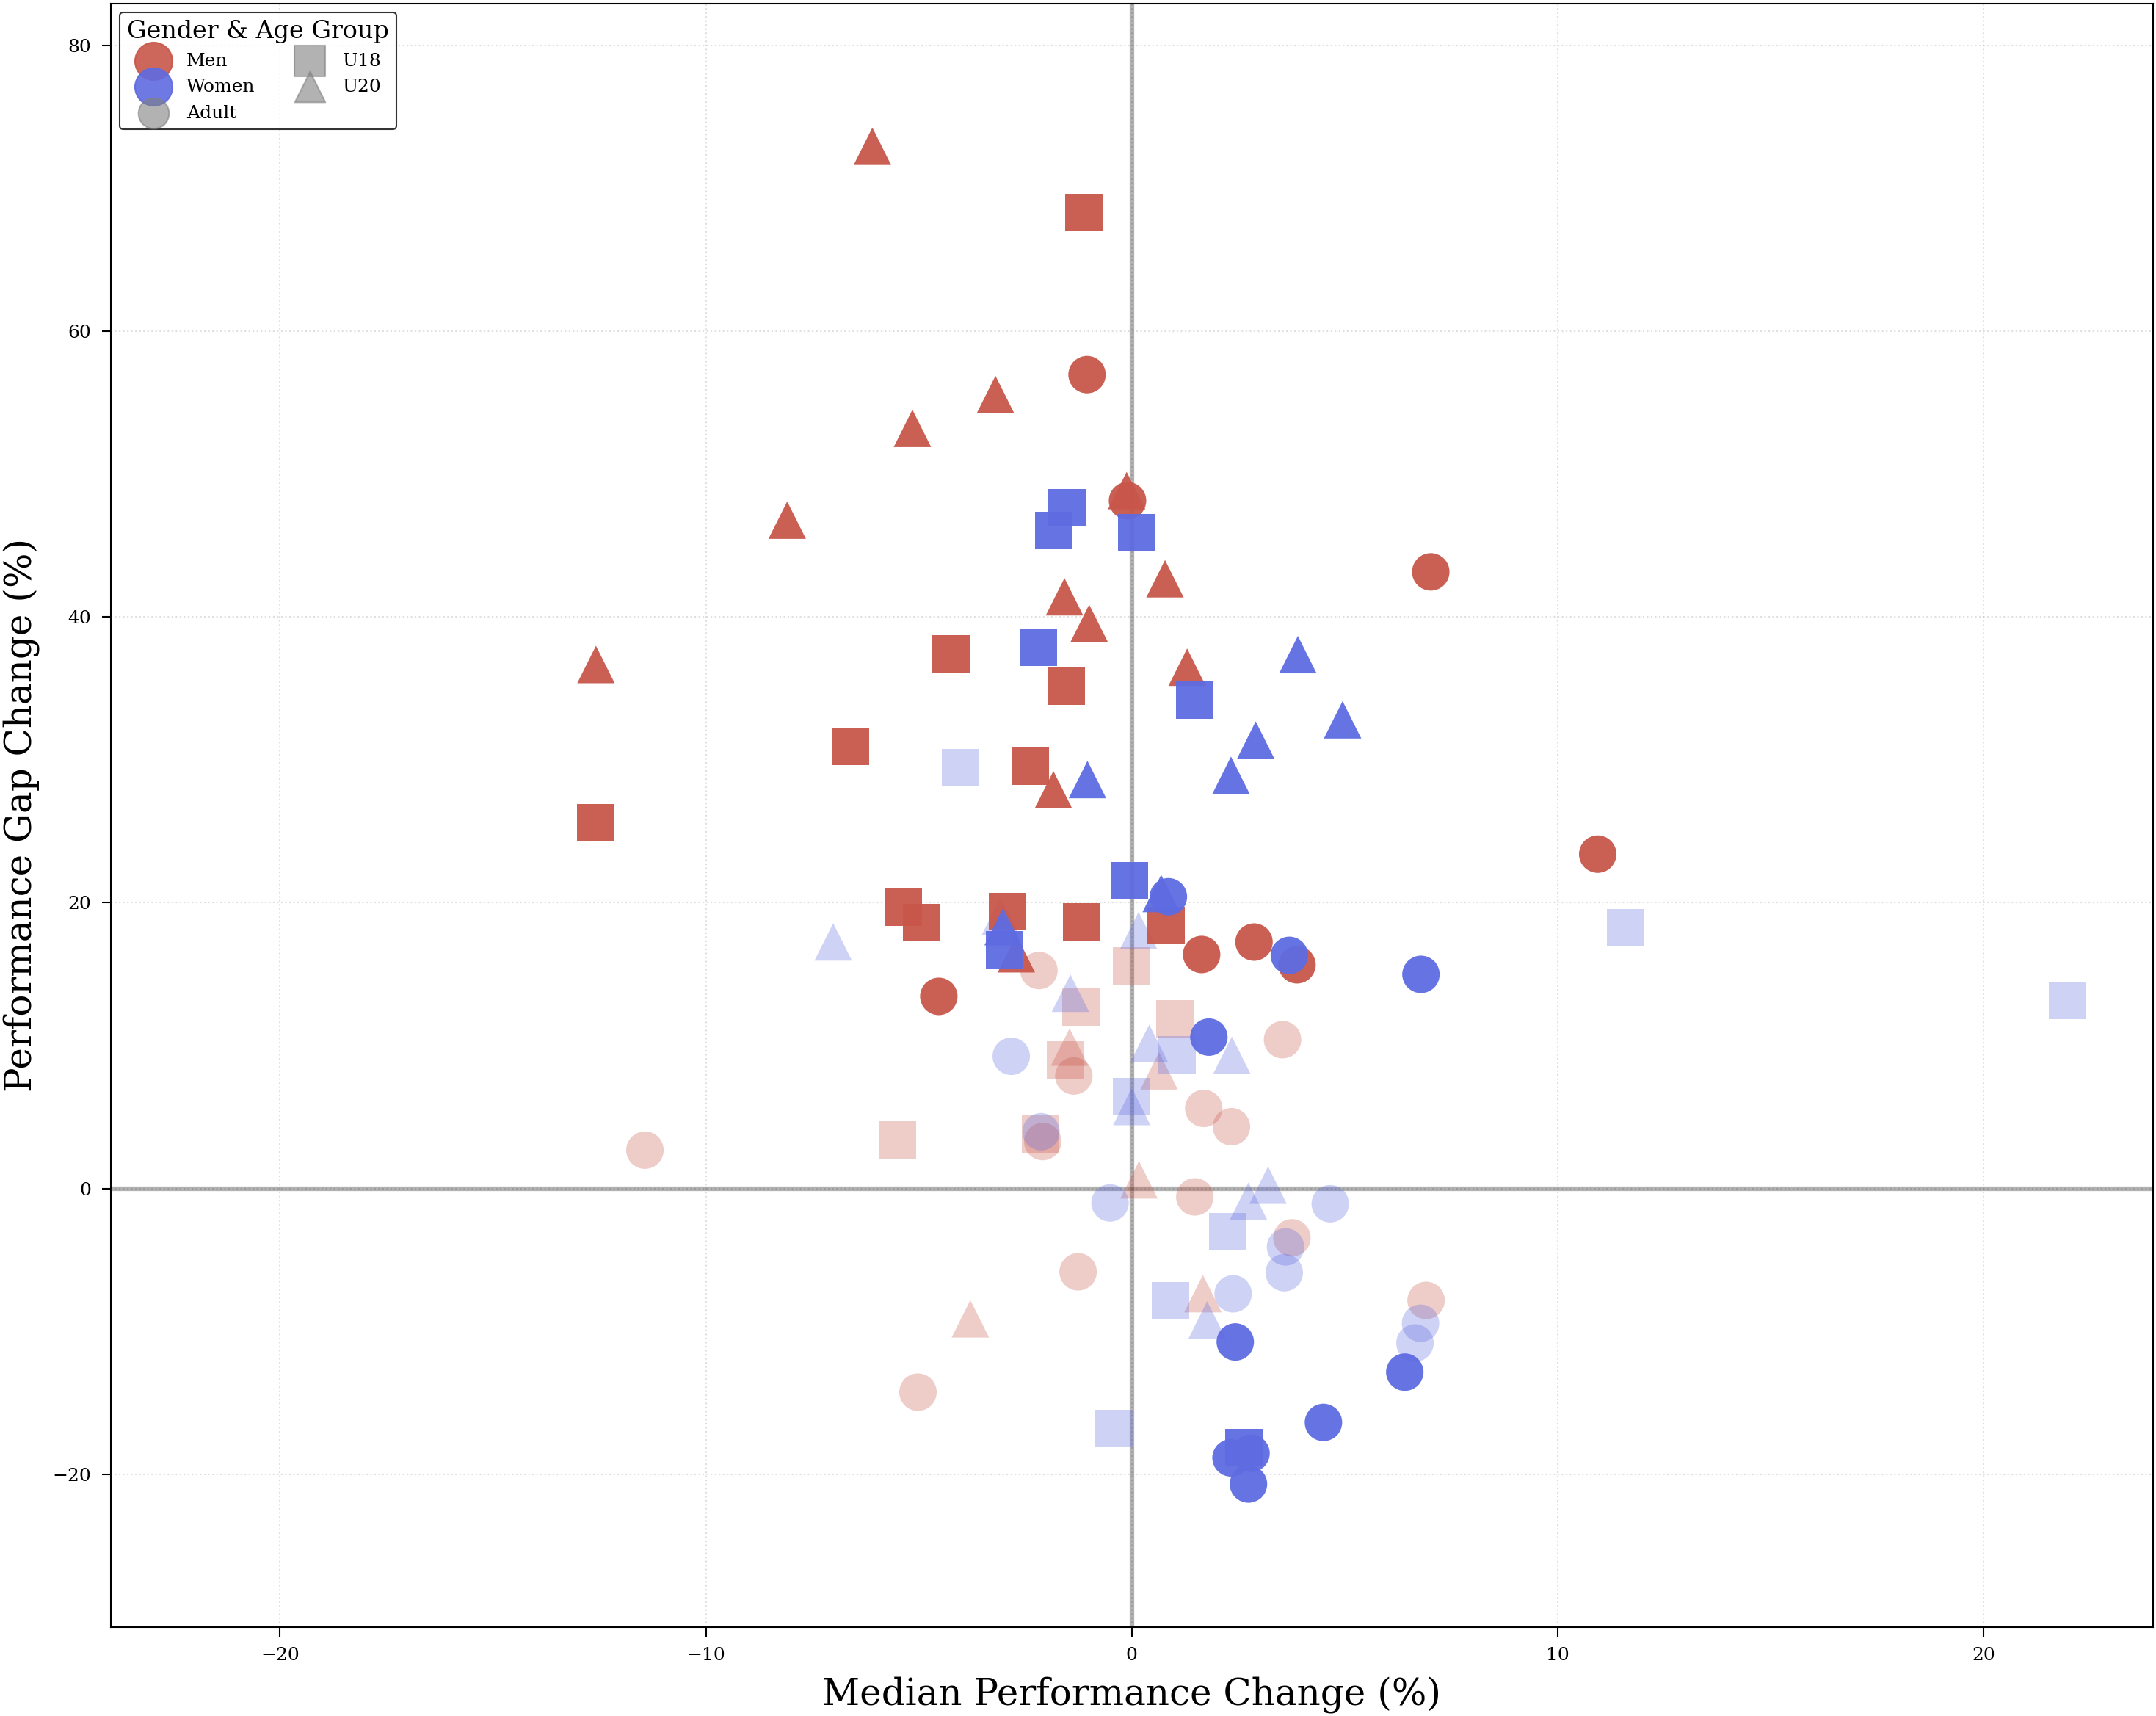

In [9]:
import matplotlib.pyplot as plt

# 1. Prepare Data
plot_data = analysis_results.copy()

# 2. Initialize Plot
fig, ax = plt.subplots(figsize=(10, 8))

# 3. Define Aesthetics
colors = {'M': "#c8564a", 'W': "#5e6be1"} 
labels = {'M': 'Men', 'W': 'Women'}

# Marker-Mapping für Altersklassen (Beispielhaft für 3 Klassen)
# 'o' = Kreis, 's' = Quadrat, '^' = Dreieck
unique_ages = sorted(plot_data['altersklasse'].unique())
marker_styles = ['o', 's', '^', 'D', 'v'] # Liste an Stilen
marker_map = {age: marker_styles[i] for i, age in enumerate(unique_ages)}

# 4. Scatter Plot
for gender in ['M', 'W']:
    if gender not in plot_data['geschlecht'].unique():
        continue

    
    
    # Legend Proxy für Geschlecht (Farbe)
    ax.scatter([], [], color=colors[gender], label=labels[gender], alpha=0.9, s=150)
    
    for age in unique_ages:
        mask = (plot_data['geschlecht'] == gender) & (plot_data['altersklasse'] == age)
        subset = plot_data[mask]
        
        if subset.empty:
            continue
            
        # A) Nicht-signifikante Punkte (hohe Transparenz, niedriger zorder)
        mask_no = subset['Gap_Sig_Bootstrap'] == 'No'
        ax.scatter(
            subset.loc[mask_no, "Median_Diff_%"], 
            subset.loc[mask_no, "Gap_Diff_%"], 
            color=colors[gender],
            marker=marker_map[age],
            s=150, 
            alpha=0.3, 
            edgecolors='none',
            zorder=3
        )
        
        # B) Signifikante Punkte (kräftige Farbe, hoher zorder)
        mask_yes = subset['Gap_Sig_Bootstrap'] == 'Yes'
        ax.scatter(
            subset.loc[mask_yes, "Median_Diff_%"], 
            subset.loc[mask_yes, "Gap_Diff_%"], 
            color=colors[gender],
            marker=marker_map[age],
            s=150,
            alpha=0.95, 
            edgecolors='none',
            zorder=4
        )

# Legend Proxy für Altersklassen (Marker-Stil)
for age in unique_ages:
    ax.scatter([], [], color='grey', marker=marker_map[age], 
               label=age, alpha=0.6, s=100)

# 5. Reference Lines
ax.axvline(0, color='black', linestyle='-', alpha=0.3, linewidth=1.5, zorder=2)
ax.axhline(0, color='black', linestyle='-', alpha=0.3, linewidth=1.5, zorder=2)

# 6. Limits & Styling
x_abs_max = max(abs(plot_data["Median_Diff_%"].min()), abs(plot_data["Median_Diff_%"].max())) + 2
ax.set_xlim(-x_abs_max, x_abs_max)

y_max = plot_data["Gap_Diff_%"].max() + 10
y_min = plot_data["Gap_Diff_%"].min() - 10
ax.set_ylim(y_min, y_max)

ax.set_xlabel("Median Performance Change (%)", fontsize=12)
ax.set_ylabel("Performance Gap Change (%)", fontsize=12)

# Legende sortieren oder kombinieren
ax.legend(title="Gender & Age Group", loc='upper left', ncol=2)
ax.grid(True, linestyle=':', alpha=0.4, zorder=0)

plt.tight_layout()
plt.show()

In [10]:
def get_quadrant(row):
    if row['Median_Diff_%'] >= 0 and row['Gap_Diff_%'] >= 0:
        return "Oben Rechts (Niveau ↑ / Gap ↑)"
    elif row['Median_Diff_%'] >= 0 and row['Gap_Diff_%'] < 0:
        return "Unten Rechts (Niveau ↑ / Gap ↓)"
    elif row['Median_Diff_%'] < 0 and row['Gap_Diff_%'] >= 0:
        return "Oben Links (Niveau ↓ / Gap ↑)"
    else:
        return "Unten Links (Niveau ↓ / Gap ↓)"

# Quadranten zuweisen
analysis_results['Quadrant'] = analysis_results.apply(get_quadrant, axis=1)

# Signifikanz-Status kombinieren
def get_sig_status(row):
    if row['MWU_sig'] == 'Yes' and row['Gap_Sig_Bootstrap'] == 'Yes':
        return "Beide Signifikant"
    elif row['MWU_sig'] == 'Yes':
        return "Nur Median Signifikant"
    elif row['Gap_Sig_Bootstrap'] == 'Yes':
        return "Nur Gap Signifikant"
    else:
        return "Nicht Signifikant"

analysis_results['Sig_Status'] = analysis_results.apply(get_sig_status, axis=1)

# Pivot-Tabelle für die finale Übersicht
quadrant_table = pd.crosstab(analysis_results['Quadrant'], analysis_results['Sig_Status'], margins=True)
quadrant_table

Sig_Status,Beide Signifikant,Nicht Signifikant,Nur Gap Signifikant,Nur Median Signifikant,All
Quadrant,,,,,
Oben Links (Niveau ↓ / Gap ↑),24,3,6,12,45
Oben Rechts (Niveau ↑ / Gap ↑),12,9,7,7,35
Unten Links (Niveau ↓ / Gap ↓),0,3,0,2,5
Unten Rechts (Niveau ↑ / Gap ↓),7,1,0,13,21
All,43,16,13,34,106


In [11]:
import pandas as pd

# 1. Define the Gap Trend (Compression vs. Polarization)
# Gap < 0: Field is getting denser (Compression)
# Gap > 0: Field is spreading out (Polarization)
# 1. Define Trend and Significance
analysis_results['Gap_Trend'] = analysis_results['Gap_Diff_%'].apply(
    lambda x: "Compression (Gap ↓)" if x < 0 else "Polarization (Gap ↑)"
)

# 2. Generate Summary with Effect Size
# We aggregate the counts AND the mean absolute effect size
summary_table = analysis_results.groupby(
    ['altersklasse', 'geschlecht', 'Gap_Trend']
).agg({
    'Gap_Sig_Bootstrap': [
        ('Non-Significant (No)', lambda x: (x == 'No').sum()),
        ('Significant (Yes)', lambda x: (x == 'Yes').sum())
    ],
    'Gap_Effect_Size': [('Avg Effect Size (d)', 'mean')]
})

# 3. Clean Multi-index columns
summary_table.columns = summary_table.columns.get_level_values(1)

# 4. Add Insights
summary_table['Total'] = summary_table['Non-Significant (No)'] + summary_table['Significant (Yes)']
summary_table['% Significant'] = (summary_table['Significant (Yes)'] / summary_table['Total'] * 100).round(1)

# 5. Reorder for readability
cols = ['Non-Significant (No)', 'Significant (Yes)', 'Total', '% Significant', 'Avg Effect Size (d)']
summary_table = summary_table[cols].round(2)

print(summary_table)


                                              Non-Significant (No)  \
altersklasse geschlecht Gap_Trend                                    
Adult        M          Compression (Gap ↓)                      5   
                        Polarization (Gap ↑)                     7   
             W          Compression (Gap ↓)                      7   
                        Polarization (Gap ↑)                     2   
U18          M          Polarization (Gap ↑)                     6   
             W          Compression (Gap ↓)                      3   
                        Polarization (Gap ↑)                     5   
U20          M          Compression (Gap ↓)                      2   
                        Polarization (Gap ↑)                     3   
             W          Compression (Gap ↓)                      2   
                        Polarization (Gap ↑)                     8   

                                              Significant (Yes)  Total  \
altersklasse ge

In [12]:
# 6. (Optional) Breakdown by Discipline Group
group_summary = analysis_results.groupby(
    ['group', 'Gap_Trend', 'Gap_Sig_Bootstrap']
).size().unstack(fill_value=0)
group_summary.columns = ['Non-Significant (No)', 'Significant (Yes)']

pd.DataFrame(group_summary)

Non-Significant (No)  Significant (Yes)
group  Gap_Trend                                                    
Jump   Compression (Gap ↓)                      6                  1
       Polarization (Gap ↑)                     9                  8
Run    Compression (Gap ↓)                      3                  2
       Polarization (Gap ↑)                     8                 15
Sprint Compression (Gap ↓)                      6                  2
       Polarization (Gap ↑)                     5                 14
Throw  Compression (Gap ↓)                      2                  1
       Polarization (Gap ↑)                     9                 12

In [13]:


# 1. Setup the 'Trend' and 'Group' logic for the Median
# We assume 'MWU_sig' and 'Median_Diff_%' exist in your analysis_results
df = analysis_results.copy()

# 2. Table 1: Median Level Significance by Discipline Group
def get_median_table(df):
    # Define trends
    df['Median_Trend'] = np.where(df['Median_Diff_%'] < 0, 'Decrease', 'Increase')
    
    # Group and count
    median_summary = df.groupby(['group', 'Median_Trend', 'MWU_sig']).size().unstack(fill_value=0)
    
    # Flatten and pivot for the desired table structure
    median_tab = median_summary.reset_index().pivot(index='group', columns='Median_Trend', values=['No', 'Yes']).fillna(0)
    
    # Rename columns for clarity
    median_tab.columns = [
        'Decrease_Total_No', 'Increase_Total_No', 
        'Decrease_Sig_Yes', 'Increase_Sig_Yes'
    ]
    
    # Calculate Totals
    median_tab['Level Decrease (Total)'] = median_tab['Decrease_Total_No'] + median_tab['Decrease_Sig_Yes']
    median_tab['Level Decrease (Significant)'] = median_tab['Decrease_Sig_Yes']
    median_tab['Level Increase (Total)'] = median_tab['Increase_Total_No'] + median_tab['Increase_Sig_Yes']
    median_tab['Level Increase (Significant)'] = median_tab['Increase_Sig_Yes']
    
    # Calculate % Significant Improvement
    median_tab['% Significant Improvement'] = (
        median_tab['Level Increase (Significant)'] / median_tab['Level Increase (Total)'] * 100
    ).round(1).astype(str) + '%'
    
    return median_tab[['Level Decrease (Total)', 'Level Decrease (Significant)', 
                       'Level Increase (Total)', 'Level Increase (Significant)', 
                       '% Significant Improvement']]

# 3. Table 2: Combined Significance Status (The "Sig_Status" Logic)
def get_sig_status_table(df):
    def categorize_sig(row):
        m_sig = row['MWU_sig'] == 'Yes'
        g_sig = row['Gap_Sig_Bootstrap'] == 'Yes'
        
        if m_sig and g_sig: return 'Beide Signifikant'
        if not m_sig and not g_sig: return 'Nicht Signifikant'
        if g_sig: return 'Nur Gap Signifikant'
        return 'Nur Median Signifikant'

    df['Sig_Status'] = df.apply(categorize_sig, axis=1)
    
    status_counts = df['Sig_Status'].value_counts().reset_index()
    status_counts.columns = ['Significance Status', 'Count (n)']
    status_counts['Percentage (%)'] = (status_counts['Count (n)'] / len(df) * 100).round(1)
    
    return status_counts

# --- EXECUTE ---
median_by_group = get_median_table(df)
overall_sig_status = get_sig_status_table(df)

print("--- TABLE: MEDIAN SIGNIFICANCE BY GROUP ---")
print(median_by_group)
print("\n--- TABLE: OVERALL SIGNIFICANCE STATUS ---")
print(overall_sig_status)

--- TABLE: MEDIAN SIGNIFICANCE BY GROUP ---
        Level Decrease (Total)  Level Decrease (Significant)  \
group                                                          
Jump                        16                            13   
Run                          8                             4   
Sprint                      10                             8   
Throw                       16                            13   

        Level Increase (Total)  Level Increase (Significant)  \
group                                                          
Jump                         8                             5   
Run                         20                            14   
Sprint                      17                            13   
Throw                        8                             5   

       % Significant Improvement  
group                             
Jump                       62.5%  
Run                        70.0%  
Sprint                     76.5%  
Throw      

In [44]:
# 1. Table 1: Detailed Median Significance (Group, Age, Gender)
def get_detailed_median_table(df):
    df = df.copy()
    df['Median_Trend'] = np.where(df['Median_Diff_%'] < 0, 'Decrease', 'Increase')
    
    # Group by demographic and trend
    # Replace 'altersklasse' and 'geschlecht' with your exact column names if different
    grouping_cols = ['altersklasse', 'geschlecht', 'Median_Trend', 'MWU_sig']
    summary = df.groupby(grouping_cols).size().unstack(fill_value=0)
    
    # Ensure columns exist
    for col in ['No', 'Yes']:
        if col not in summary.columns: summary[col] = 0
            
    summary = summary.reset_index().pivot(
        index=['altersklasse', 'geschlecht'], 
        columns='Median_Trend', 
        values=['No', 'Yes']
    ).fillna(0)
    
    # Flatten multi-index columns
    summary.columns = [f"{trend}_{sig}" for sig, trend in summary.columns]
    
    # Calculate Table Values
    res = pd.DataFrame(index=summary.index)
    res['Decr_Total'] = summary.get('Decrease_No', 0) + summary.get('Decrease_Yes', 0)
    res['Decr_Sig']   = summary.get('Decrease_Yes', 0)
    res['Incr_Total'] = summary.get('Increase_No', 0) + summary.get('Increase_Yes', 0)
    res['Incr_Sig']   = summary.get('Increase_Yes', 0)
    
    # Perc calculation
    res['% Sig. Improvement'] = (res['Incr_Sig'] / res['Incr_Total'] * 100).round(1).astype(str) + '%'
    
    return res

# 2. Table 2: Significance Status by Demographic
def get_detailed_sig_status(df):
    def categorize_sig(row):
        m_sig = row['MWU_sig'] == 'Yes'
        g_sig = row['Gap_Sig_Bootstrap'] == 'Yes'
        if m_sig and g_sig: return 'Beide Signifikant'
        if not m_sig and not g_sig: return 'Nicht Signifikant'
        if g_sig: return 'Nur Gap Signifikant'
        return 'Nur Median Signifikant'

    df['Sig_Status'] = df.apply(categorize_sig, axis=1)
    
    # Group by demographic and status
    status_summary = df.groupby(['altersklasse', 'geschlecht', 'Sig_Status']).size().unstack(fill_value=0)
    
    # Add percentage of total within that demographic
    status_summary['Total (n)'] = status_summary.sum(axis=1)
    
    return status_summary

# --- EXECUTE ---
detailed_median = get_detailed_median_table(df)
detailed_status = get_detailed_sig_status(df)

print("--- DETAILED MEDIAN SIGNIFICANCE ---")
print(detailed_median)
print("\n--- DETAILED SIG STATUS ---")
print(detailed_status)

--- DETAILED MEDIAN SIGNIFICANCE ---
                         Decr_Total  Decr_Sig  Incr_Total  Incr_Sig  \
altersklasse geschlecht                                               
Adult        M                    9         7          11         9   
             W                    3         2          16        16   
U18          M                   14        10           3         1   
             W                    7         5           9         5   
U20          M                   12        10           5         2   
             W                    5         4          12         6   

                        % Sig. Improvement  
altersklasse geschlecht                     
Adult        M                       81.8%  
             W                      100.0%  
U18          M                       33.3%  
             W                       55.6%  
U20          M                       40.0%  
             W                       50.0%  

--- DETAILED SIG STATUS ---
Sig_S

In [ ]:
data_all['rank'] = data_all.groupby(["jahr", "disziplin", "geschlecht", "altersklasse"])["iaaf_score"].rank(ascending=False, method='first')

results_ranks_disc_age = hp.calculate_rank_diff(data_all, ["group", "geschlecht", "altersklasse"], 35)
results_ranks_age      = hp.calculate_rank_diff(data_all, ["geschlecht", "altersklasse"], 35)
results_ranks_all      = hp.calculate_rank_diff(data_all, [], 35) # Leere Liste für "All"
results_ranks_group = hp.calculate_rank_diff(data_all, ["disziplin", "geschlecht", "altersklasse"], 35)
results_ranks_discipline = hp.calculate_rank_diff(data_all, ["disziplin"], 35)



In [29]:
mapping_dict = {
    **{d: 'Run' for d in ['800 m', '1500 m', '3000 m', '5000 m', '10 000 m', '10 km', 'Marathon', '2000 m Hindernis', '3000 m Hindernis']},
    **{d: 'Sprint' for d in ['100 m', '200 m', '400 m', '100 m  Huerden', '110 m Huerden', '400 m Huerden']},
    **{d: 'Throw' for d in ['Kugelstoss', 'Diskuswurf', 'Speerwurf', 'Hammerwurf']}, 
    **{d: 'Jump' for d in ['Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung']},
    **{d: 'Combined' for d in ['Zehnkampf', 'Siebenkampf']}
}

results_ranks_discipline['group'] = results_ranks_discipline['disziplin'].map(mapping_dict)

In [35]:
results_ranks_discipline['disziplin']

0         10 000 m
1         10 000 m
2         10 000 m
3         10 000 m
4         10 000 m
           ...    
3705    Weitsprung
3706    Weitsprung
3707    Weitsprung
3708    Weitsprung
3709    Weitsprung
Name: disziplin, Length: 3710, dtype: object

C:\Users\Mattis\AppData\Local\Temp\ipykernel_19984\2909062231.py:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


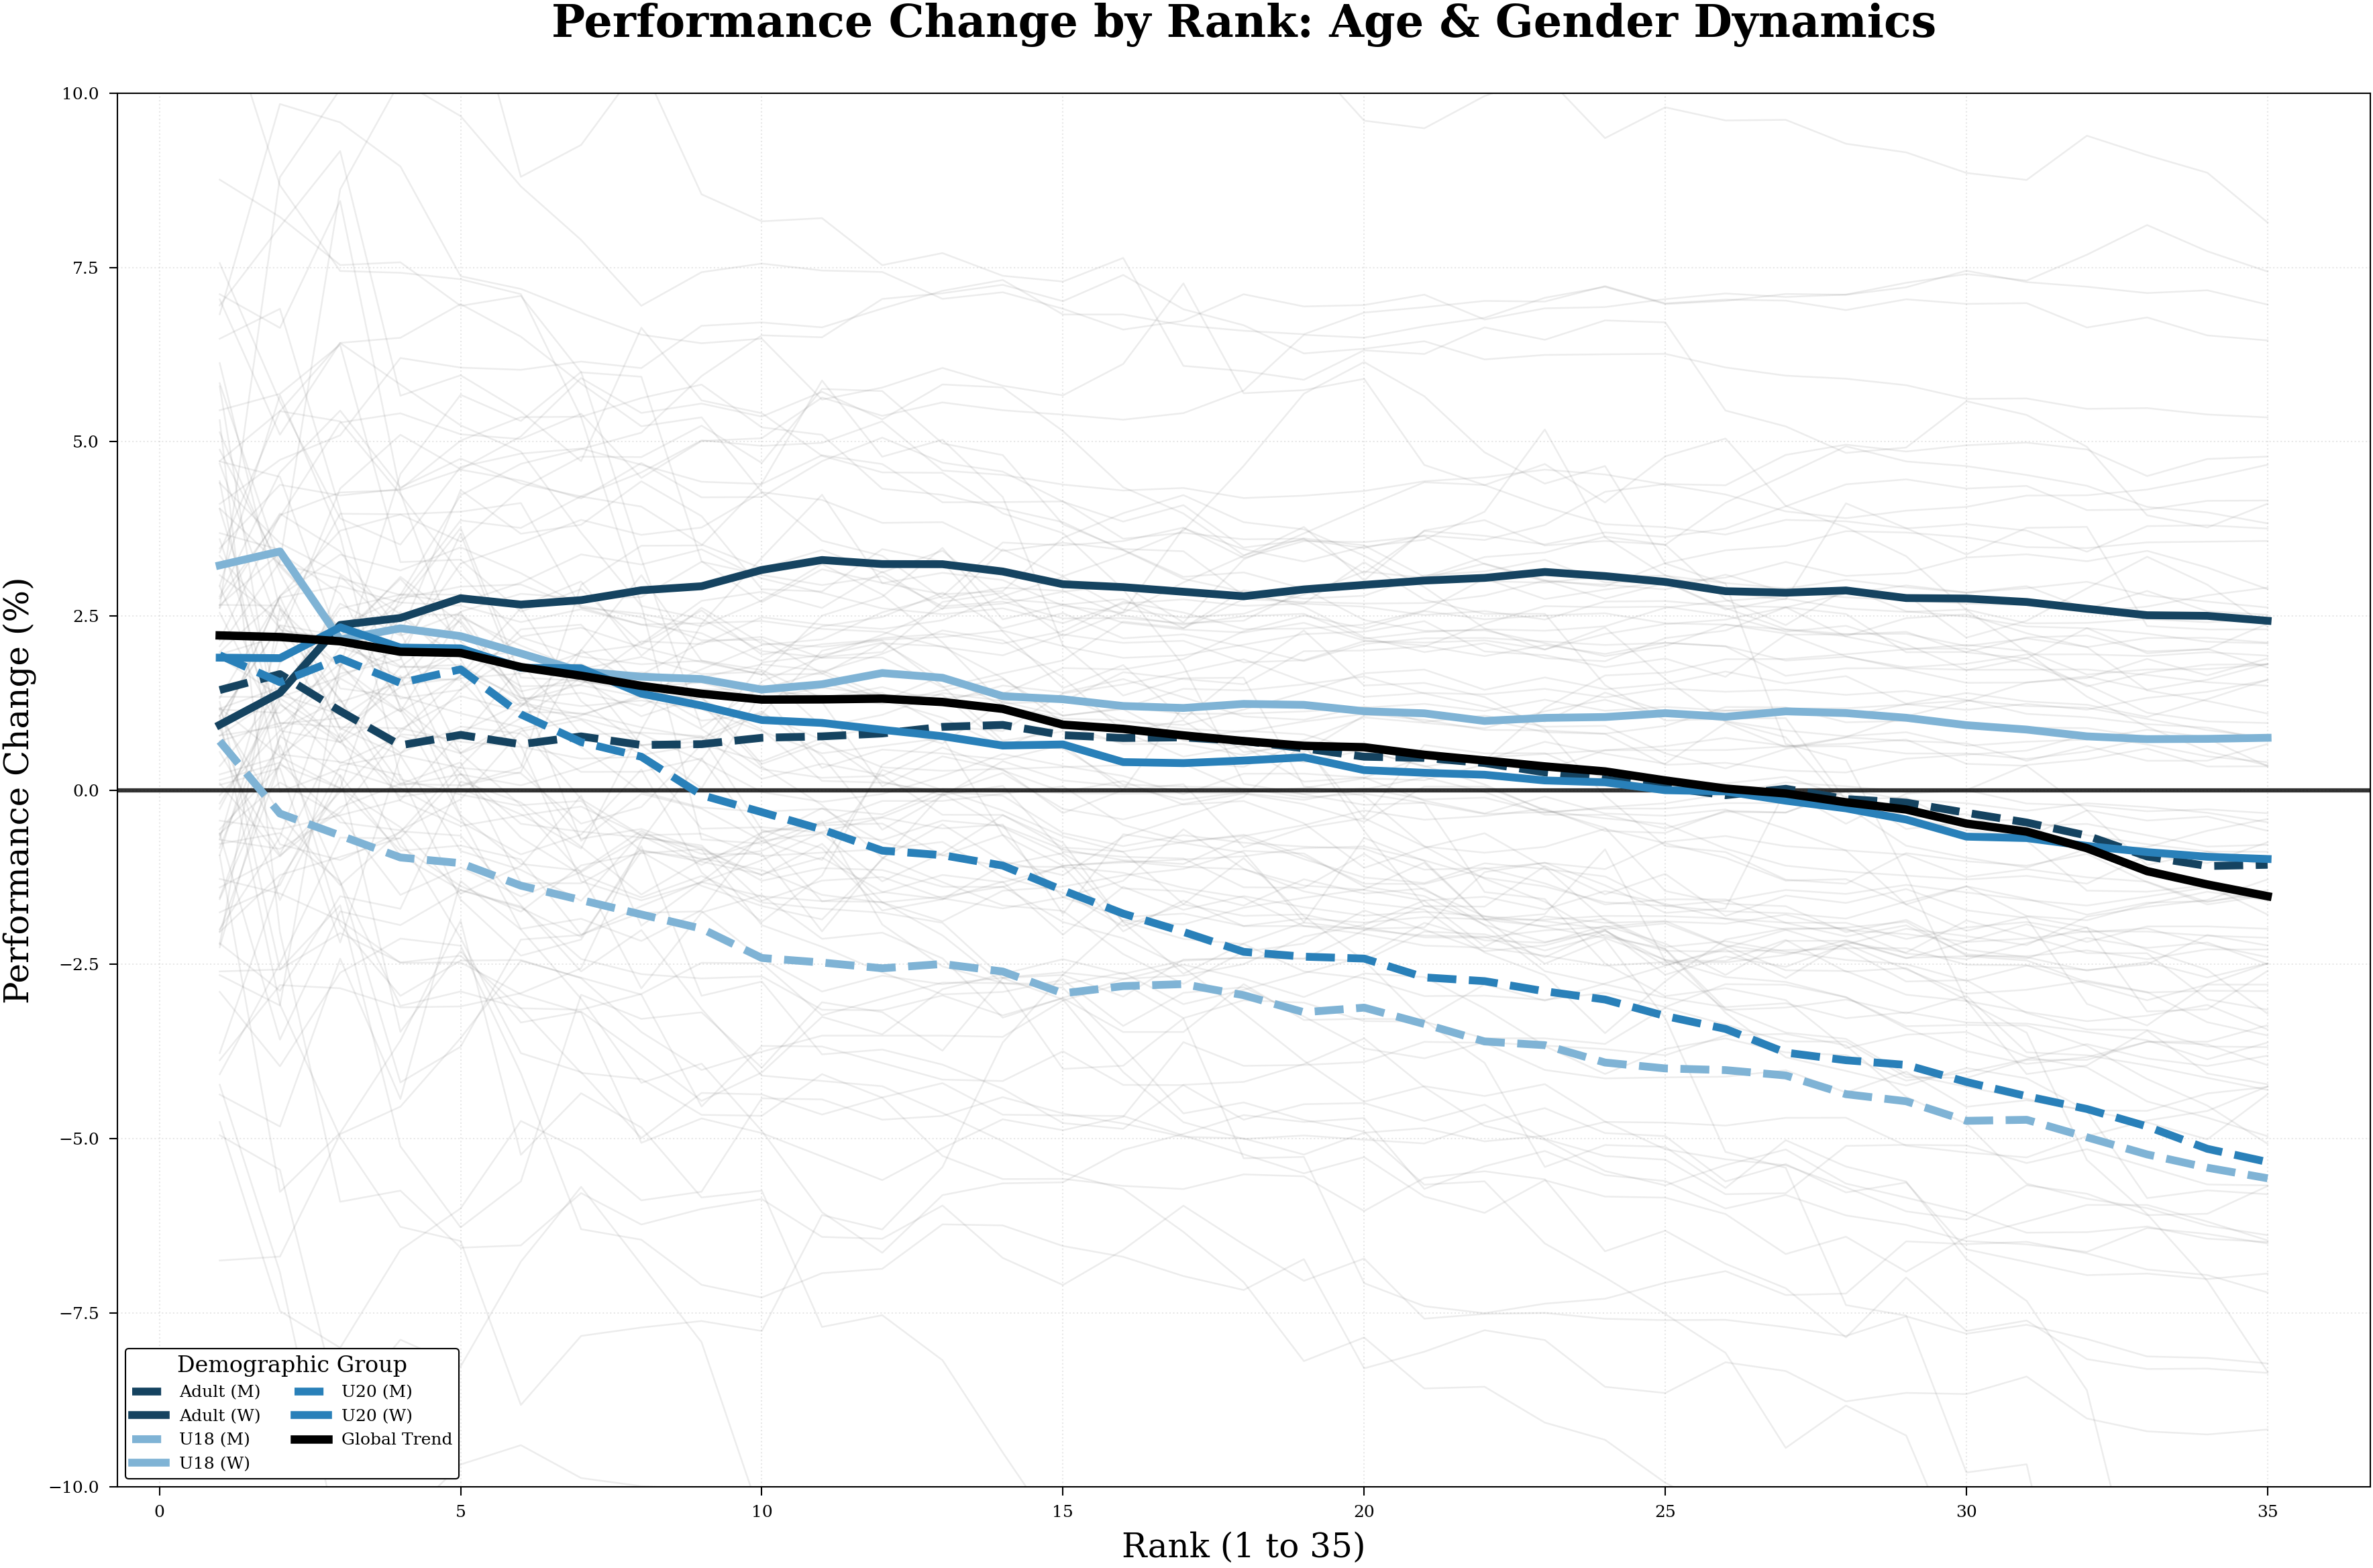

In [ ]:
import matplotlib.pyplot as plt

# 1. Setup the Plot
plt.figure(figsize=(12, 8))

# 2. Define Age-specific colors (Consistent across genders)
# Blues/Dark tones for a professional look
age_colors = {"Adult": "#154360", "U20": "#2980b9", "U18": "#7fb3d5"}

# 3. Plot ALL individual discipline-level lines in background (Light Grey)
for (disc, gender, age), disc_df in results_ranks_group.groupby(["disziplin", "geschlecht", "altersklasse"]):
    plt.plot(
        disc_df["rank"], 
        disc_df["mean_diff_perc"], 
        color="grey", 
        linewidth=0.6, 
        alpha=0.15,  # Very faint to stay in background
        zorder=1
    )

# 4. Plot Aggregated Demographic Trends
# We use Solid for Women and Dashed for Men (or vice versa)
for (age, gender), group_df in results_ranks_age.groupby(["altersklasse", "geschlecht"]):
    color = age_colors.get(age, "grey")
    # Using different styles to distinguish gender within the same color family
    linestyle = "-" if gender == "W" else "--" 
    label = f"{age} ({gender})"
    
    plt.plot(
        group_df["rank"], 
        group_df["mean_diff_perc"], 
        color=color, 
        linestyle=linestyle, 
        linewidth=2.8, 
        alpha=1.0, 
        label=label,
        zorder=4
    )

# 5. Global Trend (Thick Black Line)
plt.plot(
    results_ranks_all["rank"], 
    results_ranks_all["mean_diff_perc"], 
    color="black", 
    linewidth=3, 
    linestyle="-", 
    label="Global Trend", 
    zorder=5
)

# 6. Formatting
plt.ylim(-10, 10)
plt.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
plt.title("Performance Change by Rank: Age & Gender Dynamics", fontsize=16, pad=20, fontweight='bold')
plt.ylabel("Performance Change (%)", fontsize=12)
plt.xlabel("Rank (1 to 35)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.3)

# 7. Legend - Organized in 2 columns for clarity
plt.legend(title="Demographic Group", loc='lower left', framealpha=1.0, ncol=2)

plt.tight_layout()
plt.show()

C:\Users\Mattis\AppData\Local\Temp\ipykernel_19984\2997778986.py:51: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


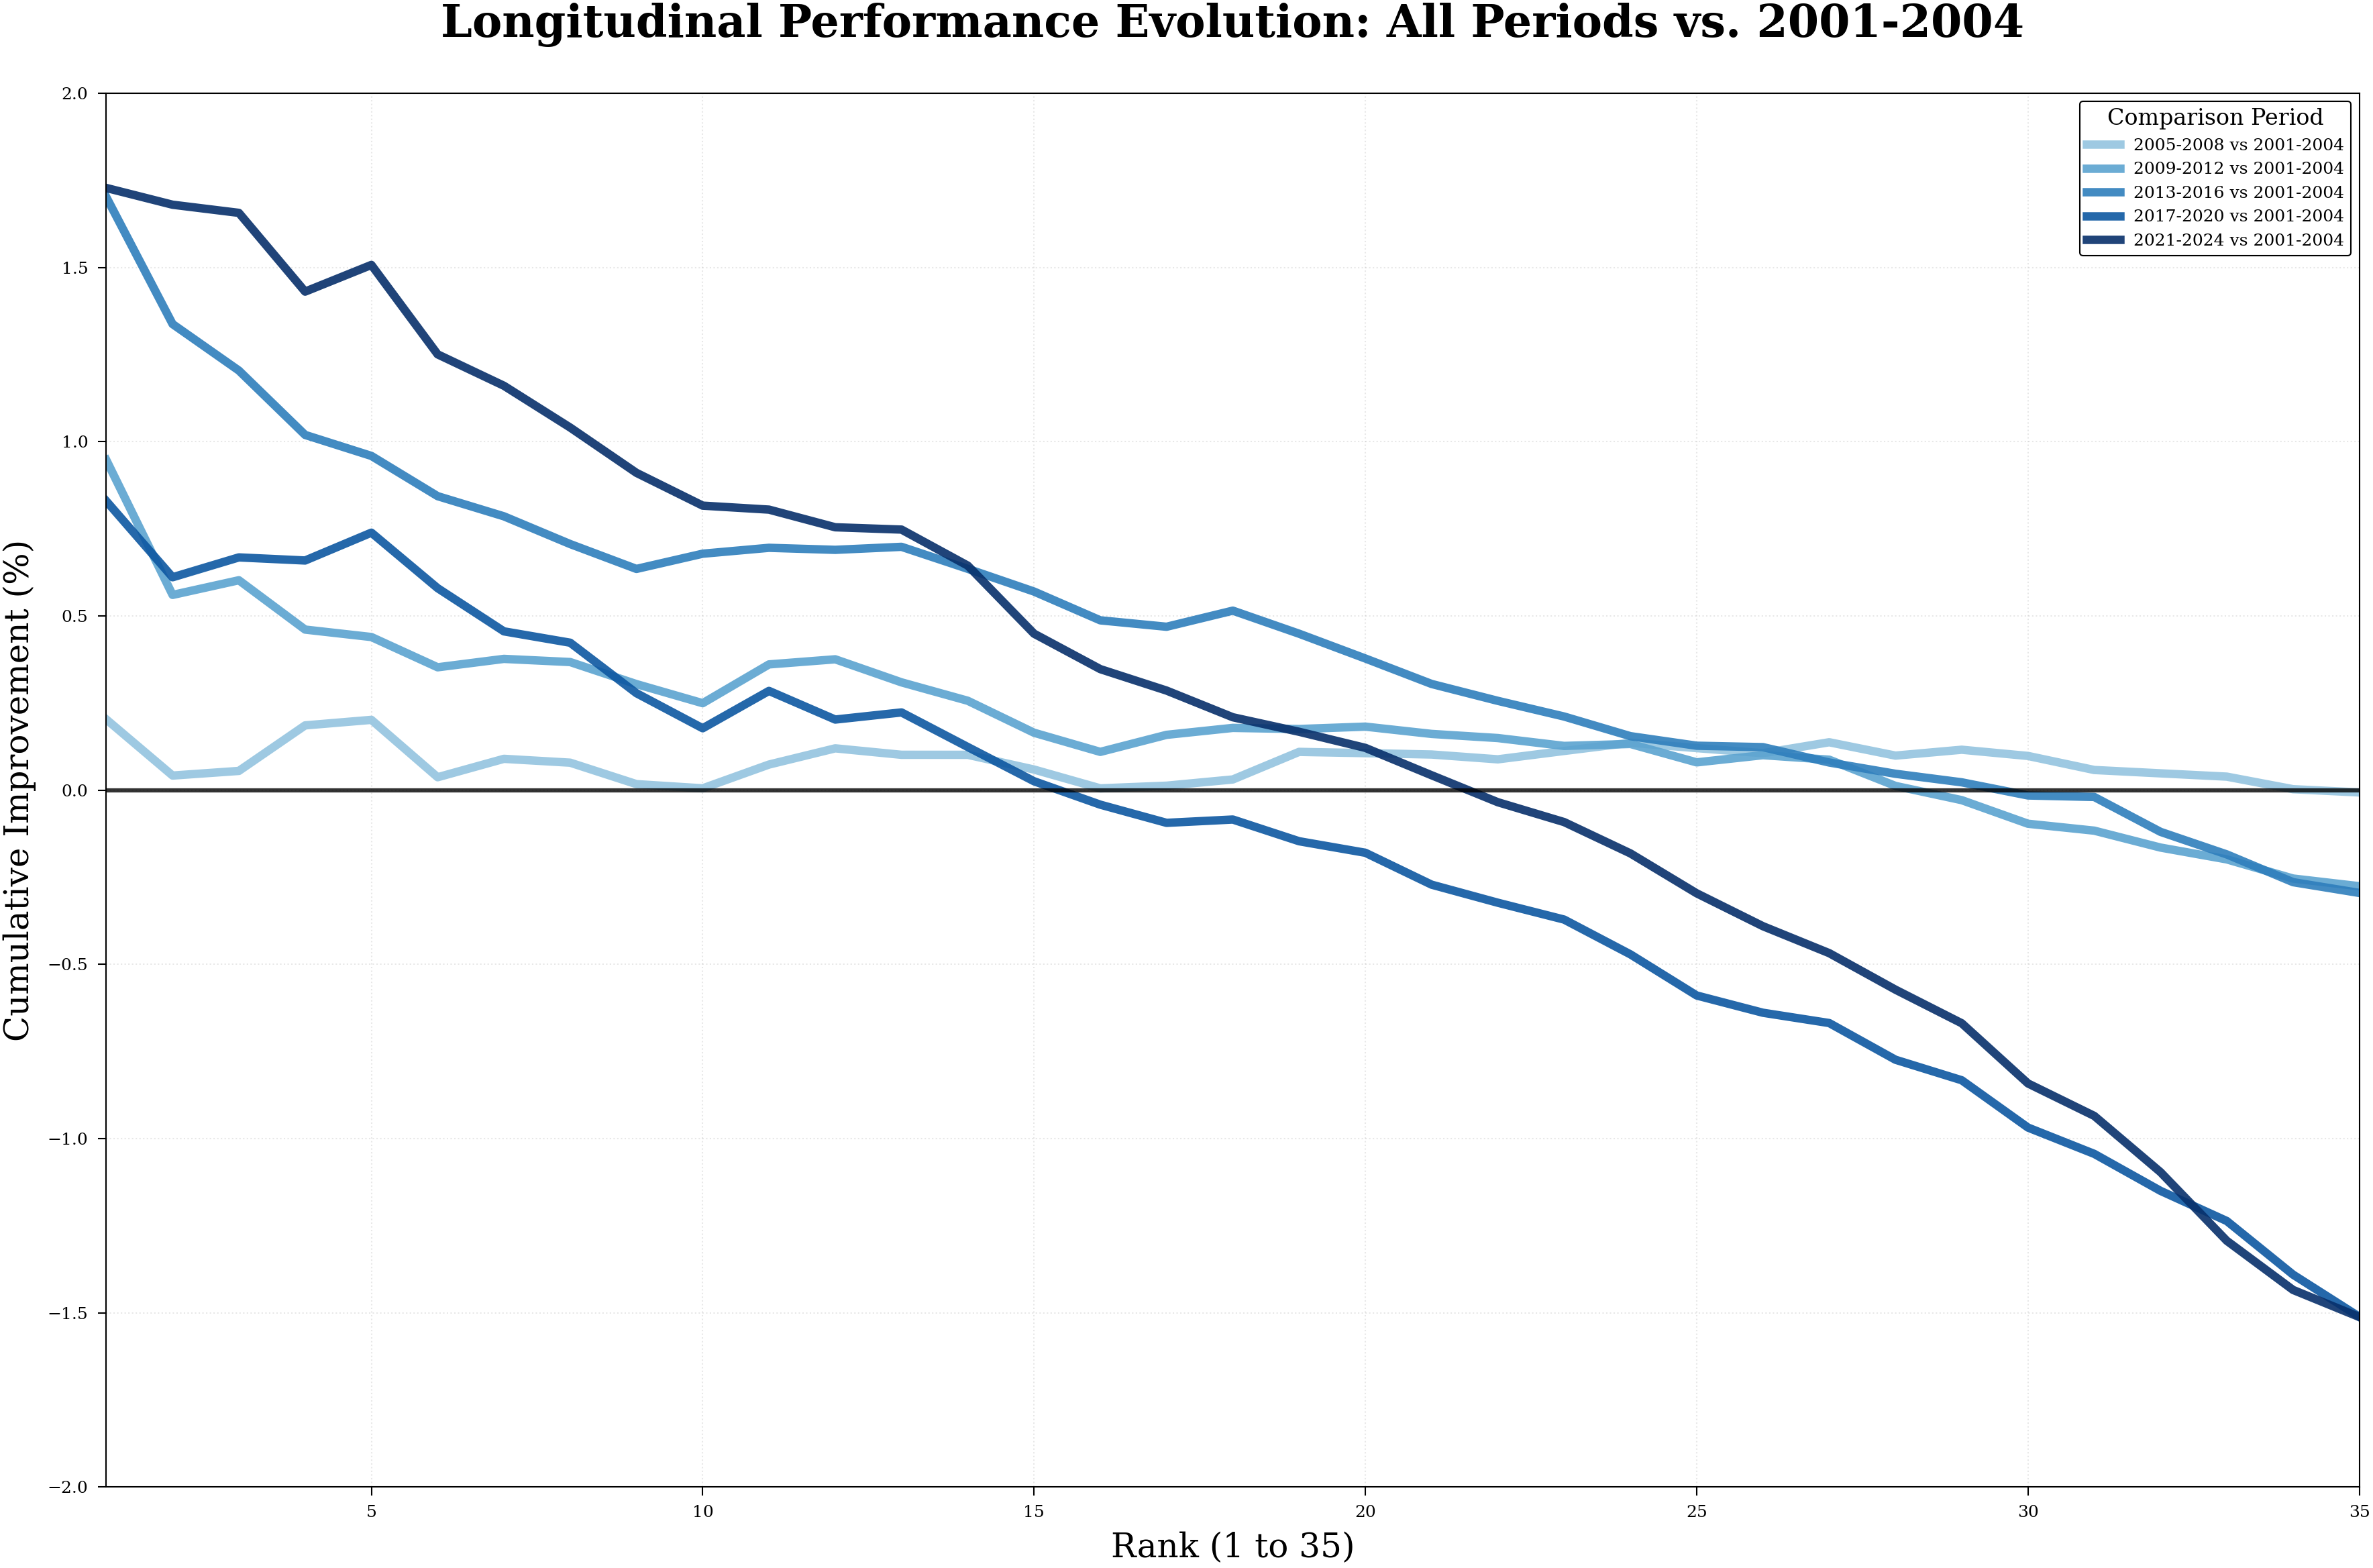

In [ ]:

# 1. Define the Baseline and Comparison Periods
# Assumes 'data_all' is your main dataframe with 'jahr', 'rank', and 'iaaf_score'
def get_period(year):
    if 2001 <= year <= 2004: return "2001-2004"
    if 2005 <= year <= 2008: return "2005-2008"
    if 2009 <= year <= 2012: return "2009-2012"
    if 2013 <= year <= 2016: return "2013-2016"
    if 2017 <= year <= 2020: return "2017-2020"
    if 2021 <= year <= 2024: return "2021-2024"
    return None

data_all['period'] = data_all['jahr'].apply(get_period)
df_filtered = data_all[data_all['period'].notna()]

# 2. Calculate Mean Score per Rank per Period (Aggregating all disciplines/ages)
overall_means = df_filtered.groupby(['period', 'rank'])['iaaf_score'].mean().unstack(level=0)

# 3. Calculate % Change Relative to 2001-2004
baseline = "2001-2004"
# (Current Period - Baseline) / Baseline * 100
overall_diff = overall_means.apply(lambda x: (x - overall_means[baseline]) / overall_means[baseline] * 100)

# 4. Setup the Plot
plt.figure(figsize=(12, 8))
plot_periods = [p for p in overall_diff.columns if p != baseline]

# Create a chronological color map (Blues or Viridis work well)
colors = plt.cm.Blues(np.linspace(0.4, 1.0, len(plot_periods)))

# 5. Plot each period vs the baseline
for i, period in enumerate(plot_periods):
    plt.plot(
        overall_diff.index, 
        overall_diff[period], 
        label=f"{period} vs {baseline}", 
        color=colors[i], 
        linewidth=3, 
        alpha=0.9
    )

# 6. Formatting
plt.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
plt.title("Longitudinal Performance Evolution: All Periods vs. 2001-2004", fontsize=16, pad=20, fontweight='bold')
plt.ylabel("Cumulative Improvement (%)", fontsize=12)
plt.xlabel("Rank (1 to 35)", fontsize=12)
plt.xlim(1, 35)
plt.ylim(-2, 2) # Adjust based on your actual data spread
plt.grid(True, linestyle=':', alpha=0.3)
plt.legend(title="Comparison Period", loc='upper right', framealpha=1.0)

plt.tight_layout()
plt.show()